In [ ]:
from pathlib import Path

from adapt_eeg.data_reader import build_metadata, read_unepoch_sample

metadata = build_metadata(Path("../data/raw/itpc-30event-good"))

In [ ]:
samples = [read_unepoch_sample(sample) for sample in metadata]

In [5]:
samples[0].__fields__

/tmp/ipykernel_489233/4000614654.py:1: PydanticDeprecatedSince20: The `__fields__` attribute is deprecated, use the `model_fields` class property instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  samples[0].__fields__


{'participant': FieldInfo(annotation=int, required=True),
 'line': FieldInfo(annotation=int, required=True),
 'set_path': FieldInfo(annotation=str, required=True),
 'fdt_path': FieldInfo(annotation=str, required=True),
 'rhythm_type': FieldInfo(annotation=RhythmType, required=True),
 'language_understanding': FieldInfo(annotation=LanguageUnderstanding, required=True),
 'data': FieldInfo(annotation=Any, required=True)}

In [11]:
samples[200].data.get_data().shape

(1, 18, 565)

(array([ 99.,   1.,   0.,  99., 101.,   0., 100.,  50.,  50.,   0.,   0.,
          0.,  49.,  51.,  50.,   0.,   0.,   0.,   0.,  50.]),
 array([460.  , 481.75, 503.5 , 525.25, 547.  , 568.75, 590.5 , 612.25,
        634.  , 655.75, 677.5 , 699.25, 721.  , 742.75, 764.5 , 786.25,
        808.  , 829.75, 851.5 , 873.25, 895.  ]),
 <BarContainer object of 20 artists>)

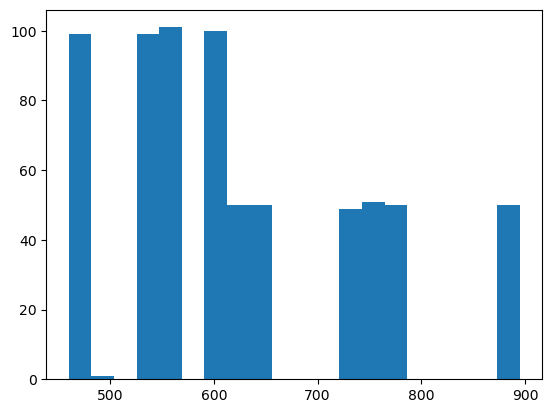

In [12]:
from matplotlib import pyplot as plt


k_values = []
for sample in samples:
    k = sample.data.get_data().shape[-1]
    k_values.append(k)
    
plt.hist(k_values, bins=20)
    

In [13]:
records = samples

In [14]:
import pandas as pd

df = pd.DataFrame(
    {
        "line": [item.line for item in records],
        "k": [item.data.get_data().shape[-1] for item in records],
    }
)

# Check whether each line has only one unique k
print(df.groupby("line")["k"].agg(["count", "nunique", "min", "max"]))

      count  nunique  min  max
line                          
1        50        1  612  612
2        50        1  612  612
3        50        1  653  653
4        50        1  750  750
5        50        1  783  783
6        50        1  537  537
7        50        1  565  565
8        50        3  460  479
9        50        2  469  490
10       50        1  616  616
15       50        2  727  750
23       50        1  895  895
27       50        1  562  562
30       50        2  540  558


In [16]:
sfreqs = {item.data.info["sfreq"] for item in records}
print(sfreqs)

{256.0}


In [21]:
mode_k = df.groupby("line")["k"].transform(lambda x: x.mode()[0])

outliers = df[df["k"] != mode_k]

print(outliers)

     line    k
430     9  490
462    15  750
531    30  558
602     8  479
622     8  467


In [22]:
import mne


data0 = mne.read_epochs_eeglab(metadata[0].set_path, verbose="ERROR")

In [25]:
anno = mne.read_annotations(metadata[0].set_path)
anno

<Annotations | 104 segments: 1 (104)>

In [34]:
anno.to_data_frame()

,onset,duration,description
0,1970-01-01 00:00:00.017253,0.0,1
1,1970-01-01 00:00:00.101562,0.0,1
2,1970-01-01 00:00:00.185875,0.0,1
3,1970-01-01 00:00:00.270183,0.0,1
4,1970-01-01 00:00:00.318031,0.0,1
...,...,...,...
99,1970-01-01 00:00:07.488937,0.0,1
100,1970-01-01 00:00:07.536781,0.0,1
101,1970-01-01 00:00:07.621093,0.0,1
102,1970-01-01 00:00:07.705406,0.0,1


In [35]:
data0

<EpochsEEGLAB | 26 events (all good), -0.102 – 0.195 s (baseline off), ~307 KiB, data loaded,
 '1/1/1/1': 26>